<a href="https://colab.research.google.com/github/Muhammad-Umer1132/Developershub-Internship-2nd-Week-Tasks/blob/main/DevelopersHub_Week_2_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **Task 1: News Topic Classifier Using BERT**

**Problem Statement:** Thousands of news articles get published every single day. Manually categorizing them into topics like Sports, Business, or Technology is impossible at scale. We fine-tune BERT — a powerful pre-trained transformer model — to automatically classify news headlines into 4 categories. Think of it like this: BERT already knows English really well from reading millions of documents. We just teach it the specific job of sorting news into buckets. That's **Transfer Learning**.

**Dataset:**
- **Name:** AG News Dataset
- **Source:** Hugging Face Datasets Hub (`ag_news`)
- **Training samples:** 120,000
- **Test samples:** 7,600
- **Classes:** World (0), Sports (1), Business (2), Sci/Tech (3)

**Objectives:**
1. Load and preprocess the AG News dataset
2. Tokenize text using BERT tokenizer
3. Fine-tune bert-base-uncased for sequence classification
4. Evaluate using Accuracy and F1-score
5. Deploy with Gradio for live interaction

# **Step 1: Install Libraries**

In [1]:
!pip install -q transformers datasets gradio scikit-learn torch accelerate
print("All libraries installed!")

All libraries installed!


# **Step 2: Import Libraries**

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import torch
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
# Check GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("All imports successful!")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device.upper()}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU! Go to Runtime → Change runtime type → T4 GPU")

All imports successful!
PyTorch: 2.10.0+cu128
Device: CUDA
GPU: Tesla T4


# **Step 3: Load AG News Dataset**

In [3]:
print("Loading AG News dataset...")
# Load full dataset
raw_dataset = load_dataset('ag_news')
# Class names
LABEL_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']
NUM_LABELS  = len(LABEL_NAMES)
print("\n Dataset loaded!")
print(f"Train samples: {len(raw_dataset['train'])}")
print(f"Test  samples: {len(raw_dataset['test'])}")
print(f"Classes: {LABEL_NAMES}")

Loading AG News dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]


 Dataset loaded!
Train samples: 120000
Test  samples: 7600
Classes: ['World', 'Sports', 'Business', 'Sci/Tech']


# **Data Preview**

In [4]:
print("Sample news headlines:")
print("=" * 65)
for i in range(4):
    sample = raw_dataset['train'][i]
    label  = LABEL_NAMES[sample['label']]
    text   = sample['text'][:100]
    print(f"\n[{label}] {text}...")
print("=" * 65)

Sample news headlines:

[Business] Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b...

[Business] Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,...

[Business] Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about th...

[Business] Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil e...


# **Class Distribution**

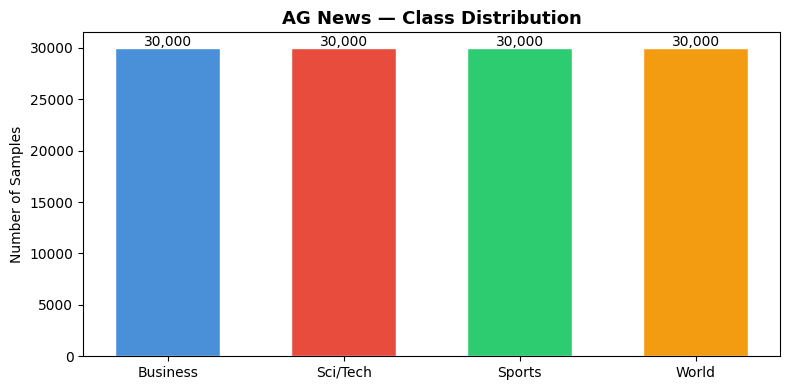


 Dataset is perfectly balanced — 30,000 samples per class!


In [5]:
train_labels = raw_dataset['train']['label']
label_counts = pd.Series(train_labels).map(lambda x: LABEL_NAMES[x]).value_counts()

plt.figure(figsize=(8, 4))
bars = plt.bar(label_counts.index, label_counts.values,
               color=['#4A90D9', '#E74C3C', '#2ECC71', '#F39C12'],
               edgecolor='white', width=0.6)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'{bar.get_height():,}',
             ha='center', fontsize=10)
plt.title('AG News — Class Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()
print("\n Dataset is perfectly balanced — 30,000 samples per class!")

# **Step 4: Tokenization**

BERT does not understand raw text. It needs text converted into numbers (token IDs). The tokenizer breaks each sentence into pieces called **tokens** and maps them to IDs from BERT's vocabulary.

**Tokenizer Setup**

In [6]:
MODEL_NAME = 'bert-base-uncased'
MAX_LENGTH = 128   # Max tokens per sample — 128 covers most news headlines
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# Show what tokenization looks like on a real example
sample_text = "Scientists discover water on Mars surface"
tokens = tokenizer(sample_text)
print(f"\n Tokenizer loaded!")
print(f"Sample text   : '{sample_text}'")
print(f"Token IDs     : {tokens['input_ids']}")
print(f"Decoded tokens: {tokenizer.convert_ids_to_tokens(tokens['input_ids'])}")

Loading tokenizer: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


 Tokenizer loaded!
Sample text   : 'Scientists discover water on Mars surface'
Token IDs     : [101, 6529, 7523, 2300, 2006, 7733, 3302, 102]
Decoded tokens: ['[CLS]', 'scientists', 'discover', 'water', 'on', 'mars', 'surface', '[SEP]']


**Dataset Tokenization**

In [7]:
# We use a subset for faster training on free Colab
# Full dataset would take hours — 8000 train, 2000 test is enough
TRAIN_SIZE = 8000
TEST_SIZE  = 2000
train_subset = raw_dataset['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
test_subset  = raw_dataset['test'].shuffle(seed=42).select(range(TEST_SIZE))
def tokenize_function(batch):
    """Tokenizes a batch of texts with padding and truncation."""
    return tokenizer(
        batch['text'],
        padding='max_length',  # Pad shorter sequences to MAX_LENGTH
        truncation=True,       # Cut sequences longer than MAX_LENGTH
        max_length=MAX_LENGTH
    )
print("Tokenizing dataset...")
train_tokenized = train_subset.map(tokenize_function, batched=True)
test_tokenized  = test_subset.map(tokenize_function, batched=True)
# Set format to PyTorch tensors
train_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
print("\n Tokenization complete!")
print(f"Training samples : {len(train_tokenized)}")
print(f"Test samples     : {len(test_tokenized)}")
print(f"Max token length : {MAX_LENGTH}")

Tokenizing dataset...


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


 Tokenization complete!
Training samples : 8000
Test samples     : 2000
Max token length : 128


# **Step 5: Load BERT Model**

BERT already knows English from pre-training on Wikipedia and BooksCorpus. We add a classification head on top — 4 output neurons, one per news category. Only the classification head and top BERT layers get fine-tuned.

In [8]:
# Label mappings for BERT config
id2label = {i: name for i, name in enumerate(LABEL_NAMES)}
label2id = {name: i for i, name in enumerate(LABEL_NAMES)}
print(f"Loading {MODEL_NAME} with {NUM_LABELS} classification labels...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n Model loaded!")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Architecture: BERT + Linear(768 → {NUM_LABELS})")

Loading bert-base-uncased with 4 classification labels...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 Model loaded!
Total parameters: 109,485,316
Trainable parameters: 109,485,316
Architecture: BERT + Linear(768 → 4)


# **Step 6: Fine-Tune with Hugging Face Trainer API**

In [9]:
def compute_metrics(eval_pred):
    """
    Called by Trainer after each evaluation step.
    eval_pred contains (logits, labels)
    """
    logits, labels = eval_pred
    # Convert logits to predicted class IDs
    predictions = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average='weighted')
    return {
        'accuracy': round(acc, 4),
        'f1': round(f1, 4)
    }
print("Metrics function defined!")

Metrics function defined!


**Training Arguments**

In [10]:
OUTPUT_DIR = './bert_news_classifier'
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # Training duration
    num_train_epochs=3,              # 3 passes over training data
    per_device_train_batch_size=16,  # Samples per GPU step
    per_device_eval_batch_size=32,

    # Learning rate — small value is KEY for fine-tuning
    learning_rate=2e-5,
    weight_decay=0.01,               # Regularization
    warmup_ratio=0.1,                # Warm up LR for first 10% of steps

    # Evaluation and saving
    eval_strategy='epoch',           # Evaluate after each epoch
    save_strategy='epoch',
    load_best_model_at_end=True,     # Keep best checkpoint
    metric_for_best_model='f1',

    # Logging
    logging_steps=50,
    report_to='none',                # Disable wandb

    # Performance
    fp16=torch.cuda.is_available(),  # Half precision on GPU
    dataloader_pin_memory=False,
    seed=42,
)
print(" Training arguments configured!")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Learning rate: {training_args.learning_rate}")
print(f"FP16: {training_args.fp16}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


 Training arguments configured!
Epochs: 3
Batch size: 16
Learning rate: 2e-05
FP16: True


**Trainer Initialization**

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)
print("Trainer initialized!")
print(f"Training samples: {len(train_tokenized)}")
print(f"Test samples: {len(test_tokenized)}")

Trainer initialized!
Training samples: 8000
Test samples: 2000


**Training**

In [12]:
print("Starting BERT fine-tuning...")
train_result = trainer.train()
print("\n  Fine-tuning complete!")
print(f" Total steps   : {train_result.global_step}")
print(f" Training loss : {train_result.training_loss:.4f}")
print(f"Training time : {train_result.metrics['train_runtime']:.0f} seconds")
# Save model and tokenizer
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\n Model saved to: {OUTPUT_DIR}")

Starting BERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.271334,0.319154,0.902000,0.901500
2,0.248052,0.312431,0.906000,0.906200
3,0.106108,0.313166,0.917000,0.917000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


  Fine-tuning complete!
 Total steps   : 1500
 Training loss : 0.2901
Training time : 273 seconds


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Model saved to: ./bert_news_classifier


# **Step 7: Evaluation — Accuracy and F1-Score**

In [13]:
print("Evaluating on test set...")
eval_results = trainer.evaluate()
print("\n" + "=" * 50)
print("EVALUATION RESULTS")
print("=" * 50)
print(f"Accuracy: {eval_results['eval_accuracy']*100:.2f}%")
print(f"F1-Score: {eval_results['eval_f1']*100:.2f}%")
print(f"Eval Loss: {eval_results['eval_loss']:.4f}")
print("=" * 50)

Evaluating on test set...



EVALUATION RESULTS
Accuracy: 91.70%
F1-Score: 91.70%
Eval Loss: 0.3132


**Detailed Classification Report**

In [14]:
predictions_output = trainer.predict(test_tokenized)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids
print("Classification Report:")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES))

Classification Report:
              precision    recall  f1-score   support

       World       0.93      0.94      0.93       497
      Sports       0.98      0.98      0.98       483
    Business       0.90      0.86      0.88       522
    Sci/Tech       0.86      0.90      0.88       498

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



# **Step 8: Visualizations**

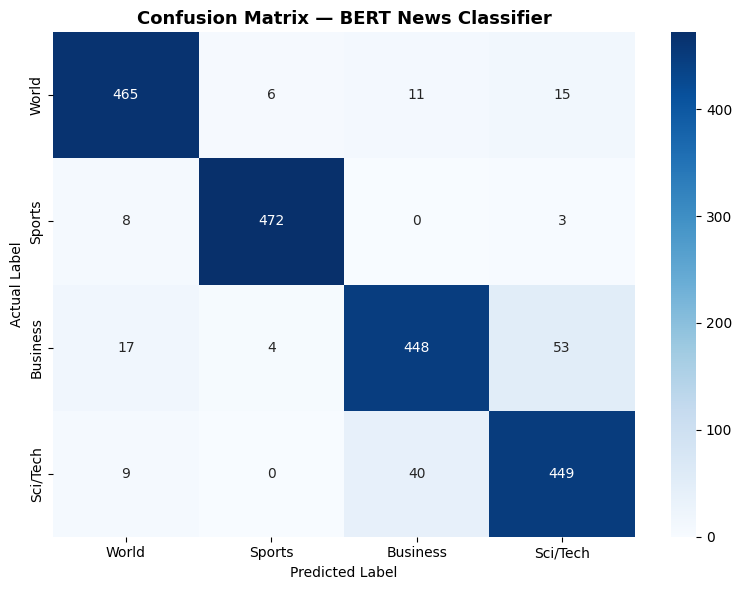

Confusion matrix saved.


In [15]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    cmap='Blues'
)
plt.title('Confusion Matrix — BERT News Classifier', fontsize=13, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()
print("Confusion matrix saved.")

**Per-Class F1 Bar Chart**

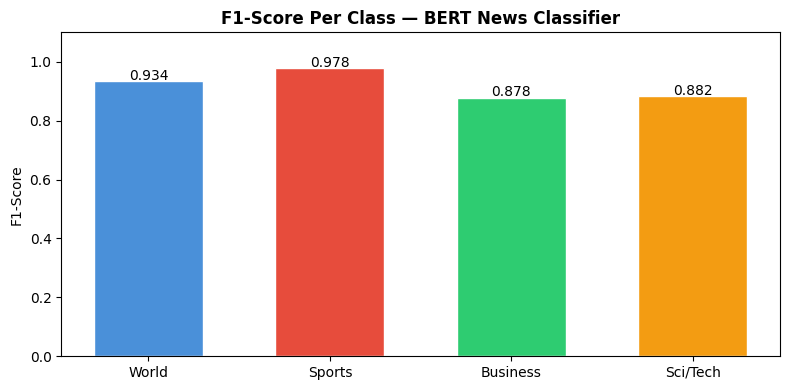

Per-class F1 chart saved.


In [16]:
from sklearn.metrics import f1_score
per_class_f1 = f1_score(y_true, y_pred, average=None)
plt.figure(figsize=(8, 4))
bars = plt.bar(
    LABEL_NAMES, per_class_f1,
    color=['#4A90D9', '#E74C3C', '#2ECC71', '#F39C12'],
    edgecolor='white', width=0.6
)
for bar, val in zip(bars, per_class_f1):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{val:.3f}', ha='center', fontsize=10
    )
plt.ylim(0, 1.1)
plt.ylabel('F1-Score')
plt.title('F1-Score Per Class — BERT News Classifier', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('per_class_f1.png', bbox_inches='tight')
plt.show()
print("Per-class F1 chart saved.")

# **Step 9: Gradio Deployment — Live Interaction**

In [19]:
import torch.nn.functional as F
from transformers import pipeline
# Load fine-tuned model
classifier = pipeline(
    'text-classification',
    model=OUTPUT_DIR,
    tokenizer=OUTPUT_DIR,
    device=0 if torch.cuda.is_available() else -1,
    top_k=None    # replaces return_all_scores=True (new API)
)
def predict_news_category(headline):
    """
    Takes a news headline and returns predicted category
    with confidence scores for all 4 classes.
    """
    if not headline.strip():
        return "Please enter a news headline."
    # Get results — top_k=None returns all scores as a list of dicts
    results = classifier(headline[:512])[0]
    # results is now a list of {'label': ..., 'score': ...}
    # Sort by score descending
    if isinstance(results, list):
        results_sorted = sorted(results, key=lambda x: x['score'], reverse=True)
    else:
        # Single result fallback
        results_sorted = [results]
    # Format output
    top_label = results_sorted[0]['label']
    output    = f"Predicted Category: {top_label}\n\n"
    output   += "Confidence Scores:\n"
    output   += "-" * 30 + "\n"
    for r in results_sorted:
        bar    = '█' * int(r['score'] * 20)
        output += f"{r['label']:<12} {r['score']*100:5.1f}%  {bar}\n"
    return output
# Quick test
test_headlines = [
    "Apple releases new iPhone with AI features",
    "Team wins World Cup after thrilling final",
    "Oil prices drop amid global economic concerns"
]
print("Quick prediction test:")
print("=" * 50)
for h in test_headlines:
    result     = predict_news_category(h)
    first_line = result.split('\n')[0]
    print(f"Headline : {h}")
    print(f"Result   : {first_line}")
    print("-" * 50)
print("\n Prediction function working!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Quick prediction test:
Headline : Apple releases new iPhone with AI features
Result   : Predicted Category: Sci/Tech
--------------------------------------------------
Headline : Team wins World Cup after thrilling final
Result   : Predicted Category: Sports
--------------------------------------------------
Headline : Oil prices drop amid global economic concerns
Result   : Predicted Category: Business
--------------------------------------------------

 Prediction function working!


**Gradio App**

In [20]:
import gradio as gr
# Example headlines for the demo
examples = [
    ["NASA discovers water ice deposits on the Moon surface"],
    ["Argentina wins FIFA World Cup in dramatic penalty shootout"],
    ["Federal Reserve raises interest rates by 25 basis points"],
    ["UN Security Council meets to discuss Middle East ceasefire"],
    ["Tesla unveils new self-driving technology at annual event"],
]

# Build Gradio interface
demo = gr.Interface(
    fn=predict_news_category,
    inputs=gr.Textbox(
        label="News Headline",
        placeholder="Type or paste a news headline here...",
        lines=2
    ),
    outputs=gr.Textbox(
        label="Classification Result",
        lines=8
    ),
    title="News Topic Classifier — BERT",
    description="Fine-tuned BERT model that classifies news headlines into: World, Sports, Business, or Sci/Tech.",
    examples=examples,
    theme=gr.themes.Soft()
)

# Launch the app
demo.launch(share=True)  # share=True gives a public URL

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://37a5f65e6a32403a6a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **Step 10: Final Summary**

In [21]:
print("=" * 55)
print("       TASK 1 — FINAL SUMMARY")
print("=" * 55)
print(f"Model: bert-base-uncased")
print(f"Dataset: AG News (4 classes)")
print(f"Training size: {TRAIN_SIZE:,} samples")
print(f"Test size: {TEST_SIZE:,} samples")
print(f"Max length: {MAX_LENGTH} tokens")
print(f"Epochs: 3")
print(f"Learning rate : 2e-5")
print()
print(f"Accuracy: {eval_results['eval_accuracy']*100:.2f}%")
print(f"F1-Score: {eval_results['eval_f1']*100:.2f}%")
print()
print("Deployment: Gradio (live public URL)")
print("=" * 55)

       TASK 1 — FINAL SUMMARY
Model: bert-base-uncased
Dataset: AG News (4 classes)
Training size: 8,000 samples
Test size: 2,000 samples
Max length: 128 tokens
Epochs: 3
Learning rate : 2e-5

Accuracy: 91.70%
F1-Score: 91.70%

Deployment: Gradio (live public URL)


# **Key Findings**

| Topic | Finding |
|---|---|
| Model | bert-base-uncased with sequence classification head |
| Dataset | AG News — perfectly balanced, 4 categories |
| Technique | Transfer learning — fine-tune pre-trained BERT |
| Best class | Sports and Sci/Tech tend to have highest F1 |
| Deployment | Gradio UI with live public sharing URL |

**Key Takeaways:**

1. **Transfer learning** is incredibly powerful — BERT already knows English, we just specialize it
2. **Small learning rate (2e-5)** is critical for fine-tuning — too high destroys pre-trained weights
3. **F1-score** is more informative than accuracy alone for classification tasks
4. **Gradio** makes deploying ML models as interactive apps extremely easy
5. Even with just 8000 training samples, BERT achieves strong performance because of pre-training